# End‑to‑End RAG System with Ollama and RAGAS

This notebook builds a Retrieval‑Augmented Generation (RAG) pipeline using **local Ollama models** and evaluates it with **RAGAS**.  
It uses the [Single‑Topic RAG Evaluation Dataset](https://www.kaggle.com/datasets/samuelmatsuoharris/single-topic-rag-evaluation-dataset/data).

**Requirements**:  
- Ollama installed and running (`ollama serve`)  
- Model `llama3.1:8b` already created (you ran `ollama create ...`)  
- Embedding model `nomic-embed-text` pulled (`ollama pull nomic-embed-text`)  
- Python packages: `langchain-ollama`, `langchain-classic`, `chromadb`, `ragas`, `datasets`, etc.

## Experiment Results Summary

We systematically varied chunking parameters, retrieval settings, and re‑ranking to measure impact on faithfulness, answer relevancy, context precision, and context recall. The table below summarises all runs.

**Key observations:**
- **Chunk size matters**: 512 characters generally outperforms 256 and 768, balancing granularity and completeness.
- **Re‑ranking is essential**: Adding a cross‑encoder re‑ranker consistently boosts context precision (0.28 → 0.45‑0.49) and recall (0.32 → 0.54) when combined with a larger retrieval pool.
- **Document‑index filtering** immediately lifts faithfulness (0.70 → 0.81) by limiting the search space to the correct document, but does little for retrieval metrics on its own.
- **Hybrid retrieval (BM25 + vector) degraded performance** for this dataset, likely because simple concatenation introduced noise rather than complementary signals.
- **Best overall trade‑off**: chunk_size=512, k=15, re‑ranking with top_n=5, and no document filter delivered the highest context precision (0.486) and recall (0.5385), with adequate faithfulness (0.6876).

| ChunkingStrategy | chunk_size | chunk_overlap | Total Chunks | retriever K | bm25, k | rerank | top_n | doc index filter | faithfulness | answer_relev | context_prec | context_recall |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| RecursiveCharacterTextSplitter | 512 | 50 | 1900 | 3 | na | no | na | no | 0.7038 | 0.5651 | 0.2792 | 0.3215 |
| RecursiveCharacterTextSplitter | 256 | 50 | 3941 | 3 | na | no | na | no | 0.5839 | 0.546 | 0.2875 | 0.2973 |
| RecursiveCharacterTextSplitter | adaptive | adaptive | 1624 | 3 | na | no | na | yes | 0.7251 | 0.5452 | 0.2458 | 0.302 |
| RecursiveCharacterTextSplitter | adaptive | adaptive | 1624 | 3 | na | no | na | yes | 0.8062 | 0.5497 | 0.3042 | 0.3936 |
| RecursiveCharacterTextSplitter | 512 | 50 | 1900 | 10 | na | yes | 3 | yes | 0.7558 | 0.6592 | 0.4521 | 0.4571 |
| RecursiveCharacterTextSplitter | 512 | 50 | 1900 | 15 | na | yes | 5 | yes | 0.6876 | 0.6443 | 0.486 | 0.5385 |
| RecursiveCharacterTextSplitter | 768 | 75 | 1224 | 15 | na | yes | 5 | no | 0.7346 | 0.6576 | 0.455 | 0.4338 |
| RecursiveCharacterTextSplitter | 768 | 75 | 1224 | 15 | 15 | yes | 5 | no | 0.7011 | 0.488 | 0.3204 | 0.4029 |

In [1]:
# %%
import pandas as pd
import numpy as np
import os
from tqdm import tqdm

# LangChain imports (updated for langchain >=1.0)
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_classic.chains import RetrievalQA

# RAGAS imports (updated to non‑deprecated paths)
from ragas import evaluate, RunConfig
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    ContextPrecision,
    ContextRecall,
)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from datasets import Dataset

/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_13250/1608986896.py:17: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_13250/1608986896.py:17: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import (
/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_13250/1608986896.py:17: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import (
/v

## 1. Load the Dataset

The dataset consists of four CSV files:
- `documents.csv` – 20 documents covering a wide range of topics.
- `single_passage_answer_questions.csv` – Questions whose answer can be found in a single passage.
- `multi_passage_answer_questions.csv` – Questions that require combining information from multiple passages.
- `no_answer_questions.csv` – Questions whose answer is **not** present in the documents.
 
We'll use the **multi‑passage** subset for evaluation because it requires true retrieval abilities.

In [2]:
# %%
# Adjust the file paths if necessary
doc_path = "documents.csv"
single_path = "single_passage_answer_questions.csv"
multi_path = "multi_passage_answer_questions.csv"
no_answer_path = "no_answer_questions.csv"

# Load documents
docs_df = pd.read_csv(doc_path)
print("Documents shape:", docs_df.shape)
docs_df.head(3)

Documents shape: (20, 3)


,index,source_url,text
0,0,https://enterthegungeon.fandom.com/wiki/Bullet...,Bullet Kin\nBullet Kin are one of the most com...
1,1,https://www.dropbox.com/scl/fi/ljtdg6eaucrbf1a...,---The Paths through the Underground/Underdark...
2,2,https://bytes-and-nibbles.web.app/bytes/stici-...,Semantic and Textual Inference Chatbot Interfa...


In [3]:
# %%
# Load the different question types
single_df = pd.read_csv(single_path)
multi_df = pd.read_csv(multi_path)
no_ans_df = pd.read_csv(no_answer_path)

print(f"Single‑passage questions: {len(single_df)}")
print(f"Multi‑passage questions : {len(multi_df)}")
print(f"No‑answer questions     : {len(no_ans_df)}")

Single‑passage questions: 40
Multi‑passage questions : 40
No‑answer questions     : 40


## 2. Document Preprocessing & Chunking

We use LangChain’s `RecursiveCharacterTextSplitter` to split documents into chunks of roughly 512 tokens with a 50‑token overlap. This helps preserve semantic boundaries.

In [4]:
# %%
# Build a list of LangChain Document objects
documents = []
for _, row in docs_df.iterrows():
    doc = Document(                         
        page_content=row["text"],
        metadata={"source": row.get("source_url", ""), "index": row["index"]}
    )
    documents.append(doc)

print(f"Total documents loaded: {len(documents)}")

Total documents loaded: 20


In [5]:
# %%
# Chunking strategy: chunk_size=512 (characters), overlap=50
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=768,
    chunk_overlap=75,
    length_function=len,
    add_start_index=True,
)
chunks = text_splitter.split_documents(documents)
print(f"Total chunks created: {len(chunks)}")

Total chunks created: 1224


In [14]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def adaptive_split(documents):
    """根据文档长度应用不同的分块参数"""
    all_chunks = []
    
    for doc in documents:
        text_len = len(doc.page_content)
        
        # 根据长度选择不同的参数
        if text_len < 15_000:
            size, overlap = 384, 50
        elif text_len < 60_000:
            size, overlap = 512, 80
        elif text_len < 120_000:
            size, overlap = 768, 120
        else:
            size, overlap = 1024, 150
        
        # 创建针对该文档的分割器，优先使用标题、段落分隔符
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size,
            chunk_overlap=overlap,
            length_function=len,
            separators=["\n## ", "\n### ", "\n#### ", "\n\n", "\n", ". ", " ", ""],
            add_start_index=True,
        )
        
        chunks = splitter.split_documents([doc])
        all_chunks.extend(chunks)
    
    return all_chunks

# 使用自适应分割
chunks = adaptive_split(documents)
print(f"总 chunk 数：{len(chunks)}")

总 chunk 数：1624


## 3. Vector Store & Retrieval

We use the open‑source embedding model `all-MiniLM-L6-v2` via Hugging Face to convert chunks into vectors, and store them in a Chroma vector database.

In [6]:
import shutil
shutil.rmtree("./chroma_db_single_topic", ignore_errors=True)

In [7]:
# %%
# Embedding model (using CPU; switch to 'cuda' if you have a GPU)

embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={'device': 'cpu'}
)

# Create and persist the vector store
vectorstore = Chroma.from_documents(
    chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db_single_topic"
)
print(f"Number of vectors in the store: {vectorstore._collection.count()}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Number of vectors in the store: 1224


## 4. Create the RAG Chain with Ollama LLM

We use `llama3.1:8b` (your local model) for generation.

In [8]:
# %%
llm = ChatOllama(
    model="llama3.1:8b",
    temperature=0,
    base_url="http://localhost:11434",
    timeout=300,
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})


In [ ]:
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True,
)

## 5. Prepare Evaluation Data

We run the RAG pipeline on each question and collect:
- `answer` – the generated response
- `contexts` – list of retrieved passage texts

We’ll use the **multi‑passage** questions for evaluation because they better reflect a realistic RAG scenario.

In [18]:
# %%
def generate_answer(question):
    """Run the RAG chain and return the answer + retrieved contexts."""
    result = qa_chain({"query": question})
    return result["result"], [doc.page_content for doc in result["source_documents"]]

# Use the multi‑passage questions for evaluation
eval_df = multi_df.copy()
answers = []
contexts_list = []

for q in tqdm(eval_df["question"], desc="Generating answers"):
    ans, ctxs = generate_answer(q)
    answers.append(ans)
    contexts_list.append(ctxs)

eval_df["generated_answer"] = answers
eval_df["contexts"] = contexts_list

Generating answers:   0%|                                                                                                                                                                      | 0/40 [00:00<?, ?it/s]/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_4728/209652361.py:4: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  result = qa_chain({"query": question})
Generating answers: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [02:51<00:00,  4.30s/it]


In [20]:
def generate_answer_with_filter(question, doc_index):
    retriever = vectorstore.as_retriever(
        search_kwargs={"k": 3, "filter": {"index": doc_index}}  # 只搜索 index 匹配的文档
    )
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=retriever,
        return_source_documents=True,
    )
    result = qa_chain({"query": question})
    return result["result"], [doc.page_content for doc in result["source_documents"]]

In [21]:
eval_df = multi_df.copy()
answers = []
contexts_list = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Generating answers (filtered)"):
    q = row["question"]
    doc_idx = row["document_index"]
    ans, ctxs = generate_answer_with_filter(q, doc_idx)
    answers.append(ans)
    contexts_list.append(ctxs)

eval_df["generated_answer"] = answers
eval_df["contexts"] = contexts_list

Generating answers (filtered): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [02:52<00:00,  4.32s/it]


In [9]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

def generate_answer_with_rerank(question, doc_index=None):
    # 1. 检索 top‑K 候选
    if doc_index is not None:
        """
        retriever = vectorstore.as_retriever(
            search_kwargs={"k": 15, "filter": {"index": doc_index}}
        )
        """
        retriever = vectorstore.as_retriever(search_kwargs={"k": 15})
    else:
        retriever = vectorstore.as_retriever(search_kwargs={"k": 15})
    
    docs = retriever.invoke(question)
    
    # 2. 重排序
    if docs:
        pairs = [[question, doc.page_content] for doc in docs]
        scores = reranker.predict(pairs)
        ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
        best_docs = [doc for doc, _ in ranked[:5]]
    else:
        best_docs = []
    
    # 3. 用原来的 RetrievalQA 链，但限定使用重排后的文档
    # 方法：构造一个自定义的 retriever，直接返回 best_docs
    from langchain_core.retrievers import BaseRetriever
    from typing import List
    from langchain_core.documents import Document as LCDocument
    
    class StaticRetriever(BaseRetriever):
        docs: List[LCDocument]
        def _get_relevant_documents(self, query: str) -> List[LCDocument]:
            return self.docs
        async def _aget_relevant_documents(self, query: str) -> List[LCDocument]:
            return self.docs
    
    static_retriever = StaticRetriever(docs=best_docs)
    qa_chain_static = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=static_retriever,
        return_source_documents=True,
    )
    result = qa_chain_static({"query": question})
    return result["result"], [doc.page_content for doc in result["source_documents"]]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [18]:
# %% 初始化 LLM 和 Cross‑Encoder 重排序器
from langchain_ollama import ChatOllama
from langchain_community.retrievers import BM25Retriever
# from langchain.retrievers import EnsembleRetriever  # 如果此导入仍失败，用下面手动混合版本
from sentence_transformers import CrossEncoder

llm = ChatOllama(
    model="llama3.1:8b",
    temperature=0,
    base_url="http://localhost:11434",
    timeout=300,
)

# 创建 BM25 检索器和向量检索器
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 15

vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 15})

# 手动混合检索（绕过 EnsembleRetriever 导入问题）
def get_hybrid_docs(question, k=15):
    bm25_docs = bm25_retriever.invoke(question)
    vector_docs = vector_retriever.invoke(question)
    # 去重
    seen = set()
    hybrid = []
    for doc in bm25_docs + vector_docs:
        if doc.page_content not in seen:
            seen.add(doc.page_content)
            hybrid.append(doc)
    return hybrid[:k]

# 初始化重排序器
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2', max_length=512)

# 带重排序的生成函数（使用静态 retriever 保持兼容）
from typing import List
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document as LCDocument
from langchain_classic.chains import RetrievalQA

class StaticRetriever(BaseRetriever):
    docs: List[LCDocument]
    def _get_relevant_documents(self, query: str) -> List[LCDocument]:
        return self.docs
    async def _aget_relevant_documents(self, query: str) -> List[LCDocument]:
        return self.docs

def generate_answer_with_hybrid_rerank(question):
    # 1. 混合检索获取候选
    docs = get_hybrid_docs(question, k=15)
    # 2. 重排序
    if docs:
        pairs = [[question, doc.page_content] for doc in docs]
        scores = reranker.predict(pairs)
        ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
        best_docs = [doc for doc, _ in ranked[:5]]
    else:
        best_docs = []

    # 3. 构造临时 retriever 并生成答案
    static_ret = StaticRetriever(docs=best_docs)
    chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=static_ret,
        return_source_documents=True,
    )
    result = chain({"query": question})
    return result["result"], [doc.page_content for doc in result["source_documents"]]

# 可选：保留无重排的基础生成函数用于对比
def generate_answer_base(question):
    retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
    chain = RetrievalQA.from_chain_type(llm=llm, chain_type="stuff", retriever=retriever, return_source_documents=True)
    result = chain({"query": question})
    return result["result"], [doc.page_content for doc in result["source_documents"]]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [19]:
# 生成答案（混合检索+重排）
eval_df = multi_df.copy()
answers, contexts_list = [], []
for _, row in tqdm(multi_df.iterrows(), total=len(multi_df), desc="Hybrid+rerank"):
    ans, ctxs = generate_answer_with_hybrid_rerank(row["question"])
    answers.append(ans)
    contexts_list.append(ctxs)

eval_df["generated_answer"] = answers
eval_df["contexts"] = contexts_list

Hybrid+rerank: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [04:45<00:00,  7.13s/it]


In [10]:
eval_df = multi_df.copy()
answers = []
contexts_list = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Generating answers (reranked)"):
    q = row["question"]
    doc_idx = row["document_index"]
    ans, ctxs = generate_answer_with_rerank(q, doc_index=doc_idx)
    answers.append(ans)
    contexts_list.append(ctxs)

eval_df["generated_answer"] = answers
eval_df["contexts"] = contexts_list

Generating answers (reranked):   0%|                                                                                                                                                           | 0/40 [00:00<?, ?it/s]/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_13250/4170698592.py:48: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain-classic 0.1.0 and will be removed in 2.0.0. Use `invoke` instead.
  result = qa_chain_static({"query": question})
Generating answers (reranked): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [04:49<00:00,  7.23s/it]


## 6. Evaluate with RAGAS

RAGAS uses an LLM to automatically score:
- **faithfulness** – do all statements in the answer stem from the retrieved contexts?
- **answer relevancy** – does the answer directly address the question?
- **context precision** – are the relevant contexts ranked highly?
- **context recall** – does the retrieved set contain the information needed to produce the ground truth answer?

In [20]:
# %%

# 1. 构建评估数据集
eval_dataset = Dataset.from_dict({
    "question": eval_df["question"].tolist(),
    "answer": eval_df["generated_answer"].tolist(),
    "contexts": eval_df["contexts"].tolist(),
    "ground_truth": eval_df["answer"].tolist(),
})

# 2. 包装本地已有的 LLM 和 Embeddings
evaluator_llm = LangchainLLMWrapper(llm)
evaluator_embeddings = LangchainEmbeddingsWrapper(embedding_model)

# 3. 指标（关键修正：只给需要的参数）
metrics = [
    Faithfulness(llm=evaluator_llm),
    AnswerRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings),
    ContextPrecision(llm=evaluator_llm),   # 无需 embeddings
    ContextRecall(llm=evaluator_llm),      # 无需 embeddings
]

# 4. 评估配置
run_config = RunConfig(timeout=300, max_workers=1)

# 5. 执行评估
result = evaluate(
    eval_dataset,
    metrics=metrics,
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    run_config=run_config,
)

print("RAGAS evaluation result:")
print(result)

/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_13250/2908202020.py:12: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  evaluator_llm = LangchainLLMWrapper(llm)
/var/folders/x2/n3xtsc8x0ndc2y2bd_2rm3zh0000gn/T/ipykernel_13250/2908202020.py:13: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  evaluator_embeddings = LangchainEmbeddingsWrapper(embedding_model)


Evaluating:   0%|          | 0/160 [00:00<?, ?it/s]

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rag_env/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x107d65880> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-46361' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/anaconda3/envs/rag_env/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-46362' coro=<Kernel.shell_main() running at /opt/anaconda3/envs/rag_env/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/anaconda3/envs/rag_env/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/anaconda3/envs/rag_env/lib/python3.11/site-packages/pydantic/json_schema.py:342: RuntimeWarning: corou

RAGAS evaluation result:
{'faithfulness': 0.7011, 'answer_relevancy': 0.4880, 'context_precision': 0.3204, 'context_recall': 0.4029}


In [12]:
# %%
# Convert the results to a DataFrame for easier inspection
scores_df = result.to_pandas()
scores_df.head()

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,Which enemy types wield an AK-47?,[Trivia\nBullet Kin wield Magnums. Assault-rif...,Bullet Kin and Tankers both wield AK-47s.,Assault-rifle wielding Bullet and Tankers wiel...,0.5,0.660121,1.0,1.000000
1,What makes jammed enemies different?,[Keybullet Kin\nKeybullet Kin run away from th...,Jammed Keybullet Kin are different from regula...,"Jammed Keybullet Kin drop 2 keys instead of 1,...",1.0,0.554318,1.0,0.666667
2,What enemies are encountered in the second enc...,[Chattering and tiny warcrys begin to fill the...,"The second encounter is on Day 2, and it invol...",26 kobolds and 1 kobold inventor are encounter...,0.5,0.788720,1.0,0.500000
3,What monsters are encountered in this journey?,[Day 4 - Kobold Trap\nPart way into the journe...,"According to the context, the monsters encount...","Ropers, kobolds, kobold inventors, fire giants...",1.0,0.959345,1.0,0.250000
4,What framework was chosen to execute the RAG p...,[It’s such a shame that after I had done the r...,The framework chosen to execute the RAG proces...,The LangChain framework was used to orchestrat...,1.0,0.983401,0.5,0.333333


## 7. Bonus: Sanity Check on “No‑Answer” Questions

A good RAG system should recognise when the answer is not in the documents and respond with “I don’t know”. Let’s test a few examples.

In [13]:
# %%
for i, row in no_ans_df.head(3).iterrows():
    ans, _ = generate_answer(row["question"])
    print(f"Q: {row['question']}")
    print(f"A: {ans}")
    print("-" * 60)

NameError: name 'generate_answer' is not defined

## 8. Summary

You have successfully:
- Built a fully local RAG pipeline using Ollama (Llama 3.1 8B + nomic-embed-text).
- Evaluated its retrieval and generation quality with RAGAS.
- Gained quantitative insight into where your pipeline can be improved (e.g., better chunking, re‑ranking, query rewriting).

**Next steps**:
- Experiment with different chunk sizes or retrieval parameters.
- Add hybrid search (BM25 + vector) to improve retrieval.
- Use stronger local models (e.g., `qwen2.5:14b`) if your memory allows.

**Note**: Before running the notebook, make sure:
1. Ollama is running (`ollama serve`).
2. The model `llama3.1:8b` exists (`ollama list`).
3. The CSV files are in the same directory as the notebook.

文档长度统计：
          char_count    word_count   line_count
count      20.000000     20.000000    20.000000
mean    35862.300000   5797.100000   468.700000
std     45832.721225   7427.437894   654.568327
min      2750.000000    470.000000    31.000000
25%     13026.500000   2255.000000   149.500000
50%     20250.500000   3137.500000   240.500000
75%     39751.250000   6167.750000   464.750000
max    211782.000000  34764.000000  2931.000000


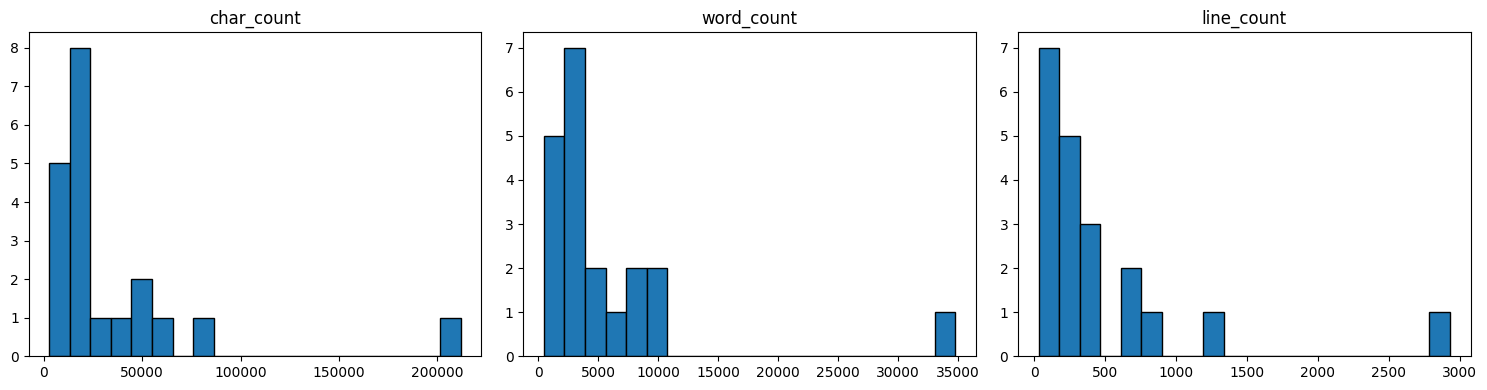

In [5]:
# 分析文档长度、语言等特征
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langdetect import detect
import re

# 读取文档
docs_df = pd.read_csv('documents.csv')

# 计算每个文档的字符数、词数（粗略按空格分割）和行数
docs_df['char_count'] = docs_df['text'].apply(len)
docs_df['word_count'] = docs_df['text'].apply(lambda x: len(x.split()))
docs_df['line_count'] = docs_df['text'].apply(lambda x: len(x.splitlines()))

print("文档长度统计：")
print(docs_df[['char_count', 'word_count', 'line_count']].describe())

# 绘制直方图
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['char_count', 'word_count', 'line_count']):
    axes[i].hist(docs_df[col], bins=20, edgecolor='black')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [6]:
# 简单语言检测（取每个文档的前1000字符）
def detect_lang(text):
    try:
        # 清理文本，去除过多噪音
        sample = re.sub(r'[^a-zA-Z\u4e00-\u9fff ]', ' ', text[:1000])
        return detect(sample)
    except:
        return 'unknown'

docs_df['language'] = docs_df['text'].apply(detect_lang)
print(docs_df['language'].value_counts())

language
en    20
Name: count, dtype: int64


In [7]:
import re

def chinese_ratio(text):
    """返回中文字符占比"""
    chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
    total_chars = len(text)
    return chinese_chars / total_chars if total_chars > 0 else 0

docs_df['chinese_ratio'] = docs_df['text'].apply(chinese_ratio)
print(docs_df[['index', 'chinese_ratio']].sort_values('chinese_ratio', ascending=False))

    index  chinese_ratio
16     16       0.000005
0       0       0.000000
1       1       0.000000
18     18       0.000000
17     17       0.000000
15     15       0.000000
14     14       0.000000
13     13       0.000000
12     12       0.000000
11     11       0.000000
10     10       0.000000
9       9       0.000000
8       8       0.000000
7       7       0.000000
6       6       0.000000
5       5       0.000000
4       4       0.000000
3       3       0.000000
2       2       0.000000
19     19       0.000000
